# Final Python Notebook 1: Data Understanding, Cleaning and Preparation

**Author:** K.Bhagya Anuhasini Silva

**Declaration:**

I hereby declare that all the codes included in this notebook were learned and developed during **Seminar Sessions 1 and 2**. The implementation and compilation of these codes are entirely my own work. I also confirm that this work has not been used in any other coursework or submitted for any other academic work previously.

**Code peer Review:**

Reviewer: Methul Welikala

Date: 18/02/2026

Test Cases:

*   Implement One-Hot Encoding Instead of Label Encoding
*   Expand for Model










In [ ]:
# import all libraries and load the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_frame = pd.read_csv("/content/loan_approval_data.csv")

In [ ]:
# displaying first five rows

data_frame.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


In [ ]:
# Program to print all the column names of the data_frame
list(data_frame.columns)

['id',
 'age',
 'income',
 'home_ownership',
 'emplyment_length',
 'loan_intent',
 'loan_amount',
 'loan_interest_rate',
 'loan_income_ratio',
 'payment_default_on_file',
 'credit_history_length',
 'loan_approval_status',
 'max_allowed_loan']

In [ ]:
# summary of data
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       58645 non-null  int64  
 1   age                      58639 non-null  float64
 2   income                   58645 non-null  int64  
 3   home_ownership           58645 non-null  object 
 4   emplyment_length         58645 non-null  int64  
 5   loan_intent              58645 non-null  object 
 6   loan_amount              58645 non-null  int64  
 7   loan_interest_rate       58634 non-null  float64
 8   loan_income_ratio        58645 non-null  float64
 9   payment_default_on_file  58640 non-null  object 
 10  credit_history_length    58645 non-null  int64  
 11  loan_approval_status     58645 non-null  int64  
 12  max_allowed_loan         58645 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 5.8+ MB


In [ ]:
# generate a statistical summary of the dataset
data_frame.describe()

,id,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status,max_allowed_loan
count,58645.000000,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000,5.864500e+04
mean,29322.000000,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382,6.975472e+04
std,16929.497605,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445,6.175091e+04
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000,-2.426900e+06
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000,3.800300e+04
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000,6.239200e+04
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000,9.271600e+04
max,58644.000000,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000,2.638778e+06


In [ ]:
data_frame.describe(include='object')

,home_ownership,loan_intent,payment_default_on_file
count,58645,58645,58640
unique,4,6,2
top,RENT,EDUCATION,N
freq,30594,12271,49940


In [ ]:
# dimensionality (size) of a DataFrame
data_frame.shape

(58645, 13)

In [ ]:
# search for missing values
data_frame.isnull().sum()

,0
id,0
age,6
income,0
home_ownership,0
emplyment_length,0
loan_intent,0
loan_amount,0
loan_interest_rate,11
loan_income_ratio,0
payment_default_on_file,5


In [ ]:
# Removing unnessary variables from the data_frame classification
data_frame.drop(["id", "max_allowed_loan"], axis=1, inplace=True)

# Check first few rows
data_frame.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0
1,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0
2,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0
3,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0
4,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0


In [ ]:
# define retained variables and target variable for classification model
retained_vars = [
    'age',
    'income',
    'home_ownership',
    'emplyment_length',
    'loan_intent',
    'loan_amount',
    'loan_interest_rate',
    'loan_income_ratio',
    'payment_default_on_file',
    'credit_history_length'
]

target_var = 'loan_approval_status'

In [ ]:
# descriptive stats for both retained variables

data_retained = data_frame[retained_vars]
data_retained.describe()



,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length
count,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000
mean,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556
std,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196
min,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000
25%,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000
50%,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000
75%,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000
max,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000


In [ ]:
# descriptive stats of target variable

target_var = 'loan_approval_status'
data_frame[target_var].describe()

,loan_approval_status
count,58645.000000
mean,0.142382
std,0.349445
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [ ]:
# print scale type of all retained variables
print(data_retained.dtypes)

age                        float64
income                       int64
home_ownership              object
emplyment_length             int64
loan_intent                 object
loan_amount                  int64
loan_interest_rate         float64
loan_income_ratio          float64
payment_default_on_file     object
credit_history_length        int64
dtype: object


In [ ]:
# print scale type of target variable
print(data_frame[target_var].dtypes)

int64


In [ ]:
# Import libraries
import plotly.express as px

# Create bar chart for target distribution
fig = px.histogram(
    data_frame,
    x=target_var,
    title='Distribution of Loan Approval Status',
    text_auto=True  # show counts on top of bars
)

# Show plot
fig.show()

In [ ]:
# task 3 - data preparation
# finding outliers
data_frame.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
age,58639.0,27.550913,6.033217,20.00,23.00,26.00,30.00,123.00
income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
emplyment_length,58645.0,4.703487,4.004982,0.00,2.00,4.00,7.00,150.00
loan_amount,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58634.0,10.677526,3.036034,-11.14,7.88,10.75,12.99,23.22
loan_income_ratio,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
credit_history_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00
loan_approval_status,58645.0,0.142382,0.349445,0.00,0.00,0.00,0.00,1.00


In [ ]:
data_frame.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
0,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0
1,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0
2,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0
3,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0
4,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
# Copy into encoded dataframe
data_frame_encoded = data_frame.copy()

# Define categorical and numeric columns
categorical_vars = ['home_ownership', 'loan_intent', 'payment_default_on_file']
numeric_vars = ['age', 'income', 'emplyment_length', 'loan_amount',
                'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']

# Apply Label Encoding to categorical columns only
le = LabelEncoder()
for col in categorical_vars:
    data_frame_encoded[col] = le.fit_transform(data_frame_encoded[col].astype(str))

print(data_frame_encoded.head())

    age  income  home_ownership  emplyment_length  loan_intent  loan_amount  \
0  21.0   12000               2                 0            1        15000   
1  21.0   13200               2                 2            1        25000   
2  23.0    9600               3                 5            3        30000   
3  40.0  182004               3                 3            1        35000   
4  40.0   90000               0                 3            2        35000   

   loan_interest_rate  loan_income_ratio  payment_default_on_file  \
0                6.99               0.12                        0   
1               16.77               0.19                        1   
2               12.42               0.31                        0   
3                8.00               0.19                        0   
4               12.42               0.39                        0   

   credit_history_length  loan_approval_status  
0                      4                     0  
1           

In [ ]:
# Function to find outliers
def find_outliers_IQR(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5*IQR
    upper = q3 + 1.5*IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers

# Dictionary to store outlier counts
outlier_counts_before = {}
outlier_counts_after = {}

# Count outliers before clipping
for col in numeric_vars:
    outlier_counts_before[col] = len(find_outliers_IQR(data_frame_encoded[col]))

# Clip outliers to IQR limits
for col in numeric_vars:
    q1 = data_frame_encoded[col].quantile(0.25)
    q3 = data_frame_encoded[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5*IQR
    upper = q3 + 1.5*IQR
    data_frame_encoded[col] = data_frame_encoded[col].clip(lower, upper)

# Count outliers after clipping
for col in numeric_vars:
    outlier_counts_after[col] = len(find_outliers_IQR(data_frame_encoded[col]))

# Print outlier counts BEFORE clipping
print("Outlier counts BEFORE clipping:\n")
for col in numeric_vars:
    print(f"{col}: {outlier_counts_before[col]} ")

print("\n-------------------------\n")

# Print outlier counts AFTER clipping
print("Outlier counts AFTER clipping:\n")
for col in numeric_vars:
    print(f"{col}: {outlier_counts_after[col]} ")

print("\nOutliers have been clipped for numeric variables.")

Outlier counts BEFORE clipping:

age: 2446 
income: 2411 
emplyment_length: 1275 
loan_amount: 2045 
loan_interest_rate: 35 
loan_income_ratio: 1210 
credit_history_length: 1993 

-------------------------

Outlier counts AFTER clipping:

age: 0 
income: 0 
emplyment_length: 0 
loan_amount: 0 
loan_interest_rate: 0 
loan_income_ratio: 0 
credit_history_length: 0 

Outliers have been clipped for numeric variables.


In [ ]:
data_frame.describe()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length,loan_approval_status
count,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000,58645.000000
mean,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556,0.142382
std,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196,0.349445
min,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000,0.000000
25%,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


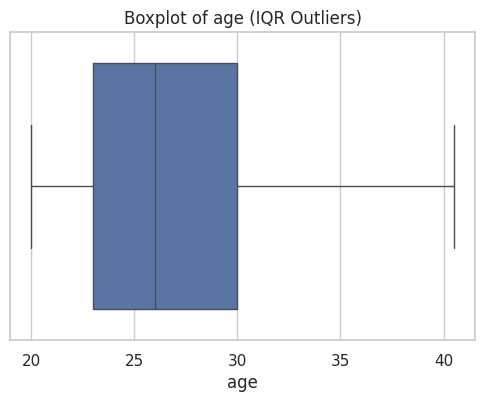

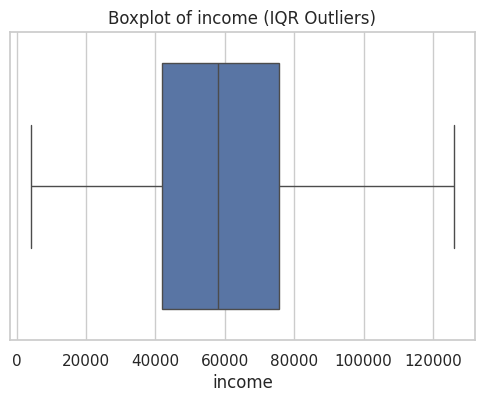

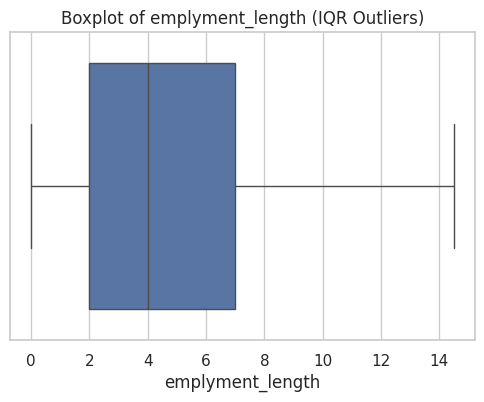

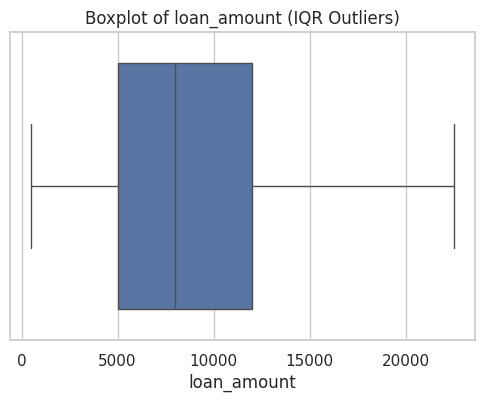

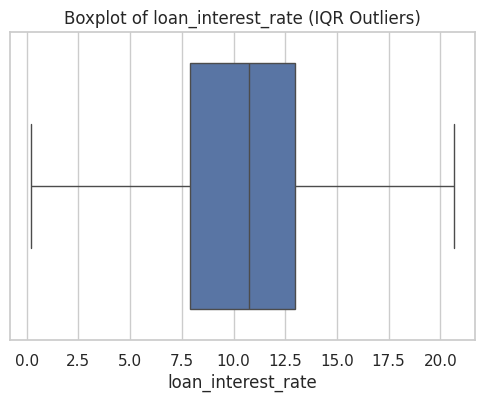

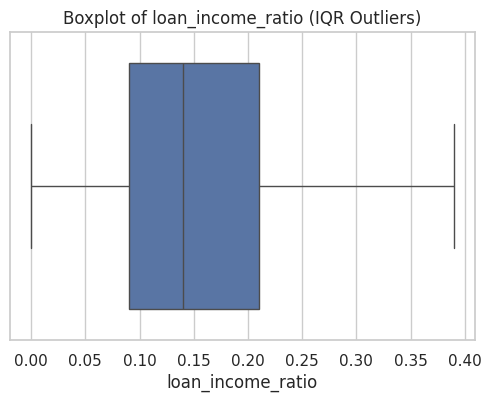

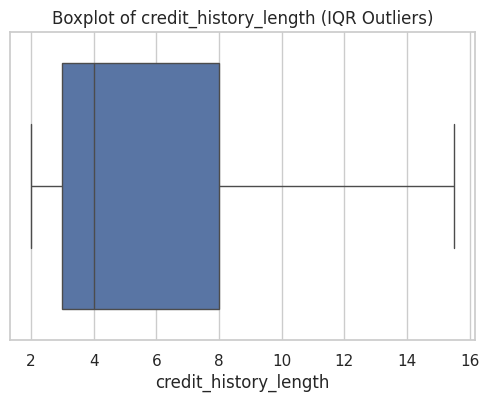

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Loop through numeric variables and plot boxplots
for col in numeric_vars:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=data_frame_encoded[col])
    plt.title(f'Boxplot of {col} (IQR Outliers)')
    plt.show()

In [ ]:
# List of retained variables
retained_vars = [
    'age',
    'income',
    'home_ownership',
    'emplyment_length',
    'loan_intent',
    'loan_amount',
    'loan_interest_rate',
    'loan_income_ratio',
    'payment_default_on_file',
    'credit_history_length'
]

# Check missing values
missing_values = data_frame[retained_vars].isna().sum()

# Print missing values per variable
print("Missing values per retained variable:")
print(missing_values)

Missing values per retained variable:
age                         6
income                      0
home_ownership              0
emplyment_length            0
loan_intent                 0
loan_amount                 0
loan_interest_rate         11
loan_income_ratio           0
payment_default_on_file     5
credit_history_length       0
dtype: int64


In [ ]:
# Fill numeric missing values with median
for col in numeric_vars:
    median_val = data_frame[col].median()
    data_frame[col].fillna(median_val, inplace=True)

# Fill categorical missing values with mode
for col in categorical_vars:
    mode_val = data_frame[col].mode()[0]
    data_frame[col].fillna(mode_val, inplace=True)

/tmp/ipykernel_5641/834909518.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_5641/834909518.py:9: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or d

In [ ]:
# print Missing values after imputation
print("Missing values after imputation:")
print(data_frame[retained_vars].isna().sum())

Missing values after imputation:
age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
dtype: int64


In [ ]:
# find duplicate rows
duplicates = data_frame.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# Z-score normalization using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = ['age','income','emplyment_length','loan_amount','loan_interest_rate','loan_income_ratio','credit_history_length']
data_frame[numeric_cols] = scaler.fit_transform(data_frame[numeric_cols])

In [ ]:
# descriptive stats fot retained data
data_retained.describe()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length
count,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000
mean,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556
std,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196
min,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000
25%,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000
50%,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000
75%,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000
max,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000


In [ ]:
# save the prepared classification dataset
data_frame.to_csv('/content/classification_dataset_prepared.csv', index=False)

In [ ]:
# preparing regrression prepared dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/loan_approval_data.csv")

In [ ]:
df.head()

,id,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,max_allowed_loan
0,35437,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,0,-2426900
1,53756,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,0,-111739
2,42205,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,0,-89000
3,19180,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0,35000
4,28072,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0,35000


In [ ]:
#Removing unnessary variables from the data_frame regression
df.drop(["id", "loan_approval_status"], axis=1, inplace=True)

# Check first few rows
df.head()

,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan
0,21.0,12000,OWN,0,EDUCATION,15000,6.99,0.12,N,4,-2426900
1,21.0,13200,OWN,2,EDUCATION,25000,16.77,0.19,Y,3,-111739
2,23.0,9600,RENT,5,MEDICAL,30000,12.42,0.31,N,3,-89000
3,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,35000
4,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,35000


In [ ]:
from sklearn.preprocessing import LabelEncoder
# Copy into encoded dataframe
data_frame_encoded = df.copy()

# Define categorical and numeric columns
categorical_vars = ['home_ownership', 'loan_intent', 'payment_default_on_file']
numeric_vars = ['age', 'income', 'emplyment_length', 'loan_amount',
                'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']

# Apply Label Encoding to categorical columns only
le = LabelEncoder()
for col in categorical_vars:
    data_frame_encoded[col] = le.fit_transform(data_frame_encoded[col].astype(str))

print(data_frame_encoded.head())

    age  income  home_ownership  emplyment_length  loan_intent  loan_amount  \
0  21.0   12000               2                 0            1        15000   
1  21.0   13200               2                 2            1        25000   
2  23.0    9600               3                 5            3        30000   
3  40.0  182004               3                 3            1        35000   
4  40.0   90000               0                 3            2        35000   

   loan_interest_rate  loan_income_ratio  payment_default_on_file  \
0                6.99               0.12                        0   
1               16.77               0.19                        1   
2               12.42               0.31                        0   
3                8.00               0.19                        0   
4               12.42               0.39                        0   

   credit_history_length  max_allowed_loan  
0                      4          -2426900  
1                   

In [ ]:
# print dataset dimensions and retained features
print("Dataset dimensions:", df.shape)
print("\nRetained Feature names:")
print(df.columns.tolist())

Dataset dimensions: (58645, 11)

Retained Feature names:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan']


In [ ]:
# define retained variables and target variable for regression model
regression_retained_vars = [
    'age',
    'income',
    'home_ownership',
    'emplyment_length',
    'loan_intent',
    'loan_amount',
    'loan_interest_rate',
    'loan_income_ratio',
    'payment_default_on_file',
    'credit_history_length'
]

regression_target_var = 'max_allowed_loan'

In [ ]:
# descriptive stats of target variable
regression_target_var = 'max_allowed_loan'
df[regression_target_var].describe()

,max_allowed_loan
count,5.864500e+04
mean,6.975472e+04
std,6.175091e+04
min,-2.426900e+06
25%,3.800300e+04
50%,6.239200e+04
75%,9.271600e+04
max,2.638778e+06


In [ ]:
# print scale type of target variable
print(df[regression_target_var].dtypes)

int64


In [ ]:
import plotly.express as px

regression_target_var = 'max_allowed_loan'
df_to_plot = df

# Create bar chart for target distribution
fig = px.histogram(
    df_to_plot,
    x=regression_target_var,
    title='Distribution of Maximum Loan Amount',
    text_auto=True  # show counts on top of bars
)

# Show plot
fig.show()

In [ ]:
# task 3 - data preparation
# finding outliers
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,58639.0,27.550913,6.033217,20.00,23.00,26.00,30.00,123.00
income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
emplyment_length,58645.0,4.703487,4.004982,0.00,2.00,4.00,7.00,150.00
loan_amount,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58634.0,10.677526,3.036034,-11.14,7.88,10.75,12.99,23.22
loan_income_ratio,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
credit_history_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00
max_allowed_loan,58645.0,69754.717828,61750.913820,-2426900.00,38003.00,62392.00,92716.00,2638778.00


In [ ]:
# Separate numeric and categorical columns
regression_numeric_vars = df[regression_retained_vars].select_dtypes(include='number').columns.tolist()
regression_categorical_vars = df[regression_retained_vars].select_dtypes(include='object').columns.tolist()

print("Numeric columns:", regression_numeric_vars)
print("Categorical columns:", regression_categorical_vars)

Numeric columns: ['age', 'income', 'emplyment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'credit_history_length']
Categorical columns: ['home_ownership', 'loan_intent', 'payment_default_on_file']


In [ ]:
# Function to find outliers
def find_outliers_IQR(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5*IQR
    upper = q3 + 1.5*IQR
    outliers = series[(series < lower) | (series > upper)]
    return outliers

# Dictionary to store outlier counts
outlier_counts_before = {}
outlier_counts_after = {}

# Count outliers before clipping
for col in numeric_vars:
    outlier_counts_before[col] = len(find_outliers_IQR(data_frame_encoded[col]))

# Clip outliers to IQR limits
for col in numeric_vars:
    q1 = data_frame_encoded[col].quantile(0.25)
    q3 = data_frame_encoded[col].quantile(0.75)
    IQR = q3 - q1
    lower = q1 - 1.5*IQR
    upper = q3 + 1.5*IQR
    data_frame_encoded[col] = data_frame_encoded[col].clip(lower, upper)

# Count outliers after clipping
for col in regression_numeric_vars:
    outlier_counts_after[col] = len(find_outliers_IQR(data_frame_encoded[col]))

# Print outlier counts BEFORE clipping
print("Outlier counts BEFORE clipping:\n")
for col in regression_numeric_vars:
    print(f"{col}: {outlier_counts_before[col]} ")

print("\n-------------------------\n")

# Print outlier counts AFTER clipping
print("Outlier counts AFTER clipping:\n")
for col in regression_numeric_vars:
    print(f"{col}: {outlier_counts_after[col]} ")

print("\nOutliers have been clipped for numeric variables.")

Outlier counts BEFORE clipping:

age: 2446 
income: 2411 
emplyment_length: 1275 
loan_amount: 2045 
loan_interest_rate: 35 
loan_income_ratio: 1210 
credit_history_length: 1993 

-------------------------

Outlier counts AFTER clipping:

age: 0 
income: 0 
emplyment_length: 0 
loan_amount: 0 
loan_interest_rate: 0 
loan_income_ratio: 0 
credit_history_length: 0 

Outliers have been clipped for numeric variables.


In [ ]:
# List of retained variables
regression_retained_vars = [
    'age',
    'income',
    'home_ownership',
    'emplyment_length',
    'loan_intent',
    'loan_amount',
    'loan_interest_rate',
    'loan_income_ratio',
    'payment_default_on_file',
    'credit_history_length'
]

# Check missing values
missing_values = df[regression_retained_vars].isna().sum()

# Print missing values per variable
print("Missing values per retained variable:")
print(missing_values)

Missing values per retained variable:
age                         6
income                      0
home_ownership              0
emplyment_length            0
loan_intent                 0
loan_amount                 0
loan_interest_rate         11
loan_income_ratio           0
payment_default_on_file     5
credit_history_length       0
dtype: int64


In [ ]:
# Fill numeric missing values with median
for col in regression_numeric_vars:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

# Fill categorical missing values with mode
for col in regression_categorical_vars:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)

/tmp/ipykernel_5641/1394104229.py:4: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



/tmp/ipykernel_5641/1394104229.py:9: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or

In [ ]:
# print Missing values after imputation
print("Missing values after imputation:")
print(df[regression_retained_vars].isna().sum())

Missing values after imputation:
age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
dtype: int64


In [ ]:
# find duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:
# Z-score normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
regression_numeric_cols = ['age','income','emplyment_length','loan_amount','loan_interest_rate','loan_income_ratio','credit_history_length']
df[numeric_cols] = scaler.fit_transform(df[regression_numeric_cols])

In [ ]:
# descriptive stats for retained data
data_retained.describe()

,age,income,emplyment_length,loan_amount,loan_interest_rate,loan_income_ratio,credit_history_length
count,58639.000000,5.864500e+04,58645.000000,58645.000000,58634.000000,58645.000000,58645.000000
mean,27.550913,6.404617e+04,4.703487,9217.556518,10.677526,0.159238,5.813556
std,6.033217,3.793111e+04,4.004982,5563.807384,3.036034,0.091692,4.029196
min,20.000000,4.200000e+03,0.000000,500.000000,-11.140000,0.000000,2.000000
25%,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000
50%,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000
75%,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000
max,123.000000,1.900000e+06,150.000000,35000.000000,23.220000,0.830000,30.000000


In [ ]:
# save prepared regression dataset
df.to_csv('/content/Regression_dataset_prepared.csv', index=False)